In [32]:
# 한글 폰트 설치 및 설정하기

!pip install statsmodels scikit-learn
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

'sudo'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'sudo'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [33]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.power import TTestIndPower
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

문제 1 · 펭귄 두 종의 몸무게는 정말 다를까? 난이도 하 · 예상 20분

📖 상황

▸
7장에서 Adelie 수컷만 골라 회귀했을 때 p-값이 0.05를 넘어 기각에 실패했습니다. 그때 우리는 "표본이 작아서"라고 정리했습니다.

▸
이제 반대편에서 물어봅니다. 표본을 아주 크게 만들면 어떤 일이 벌어질까요?

▸
실제 팔머 기지 데이터에서 Adelie와 Chinstrap의 몸무게는 평균 32g밖에 차이나지 않습니다. 펭귄 한 마리 몸무게(약 3,700g)의 1%도 안 되는 차이입니다.

▸
이 32g을 붙잡고 표본만 늘려 가면, p-값은 어디까지 내려갈까요?

🎯 이 문제로 배우는 것

▸
**"표본크기 n이 커지면 p-값은 작아진다"**는 강의 9장의 명제를 실제 데이터로 확인하고, 그래서 **효과크기(Effect Size)**를 함께 봐야 하는 이유를 숫자로 이해합니다.

In [34]:
# 문제 1 · 데이터 준비 — 실행만 하세요
penguins = sns.load_dataset('penguins')
mass = penguins.dropna(subset=['body_mass_g', 'species'])

adelie    = mass.loc[mass['species'] == 'Adelie',    'body_mass_g']
chinstrap = mass.loc[mass['species'] == 'Chinstrap', 'body_mass_g']

print("Adelie    n=%3d   평균 %.1f g   표준편차 %.1f g" % (len(adelie),    adelie.mean(),    adelie.std(ddof=1)))
print("Chinstrap n=%3d   평균 %.1f g   표준편차 %.1f g" % (len(chinstrap), chinstrap.mean(), chinstrap.std(ddof=1)))

diff_g = adelie.mean() - chinstrap.mean()
print("\n두 종의 평균 차이: %.1f g  (Adelie 몸무게의 약 %.1f%%)" % (diff_g, abs(diff_g) / adelie.mean() * 100))

Adelie    n=151   평균 3700.7 g   표준편차 458.6 g
Chinstrap n= 68   평균 3733.1 g   표준편차 384.3 g

두 종의 평균 차이: -32.4 g  (Adelie 몸무게의 약 0.9%)


Q1 · 두 종의 몸무게를 t-검정으로 비교해 봅시다

▸
adelie와 chinstrap의 몸무게에 대해 **이표본 t-검정(Two-sample t-Test)**을 수행하세요. 5-6장 실습에서 쓴 그 검정입니다.

▸
유의수준 0.05를 기준으로 "기각한다 / 기각하지 못한다"까지 문장으로 출력하세요.

In [35]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(adelie, chinstrap)

print("t-통계량 = %.4f" % t_stat)
print("p-값     = %.4f" % p_value)

t-통계량 = -0.5081
p-값     = 0.6119


Q2 · 효과크기(Cohen's d)를 직접 계산해 봅시다

▸ 강의 9장의 공식대로 cohen_d(x, y) 함수를 직접 만드세요. Q3에서 계속 씁니다.

▸ 분자: 두 집단 평균의 차이

▸ 분모: 통합 표준편차 

▸ 만든 함수로 adelie와 chinstrap의 효과크기를 계산해 출력하세요.

▸ Cohen의 관례적 기준(0.2 작음 / 0.5 중간 / 0.8 큼)에서 어디에 놓이는지도 함께 적으세요.

In [36]:
def cohen_d(x, y):
    nx, ny = len(x), len(y)
    sx, sy = np.std(x, ddof=1), np.std(y, ddof=1)
    pooled_s = np.sqrt(((nx - 1) * sx**2 + (ny - 1) * sy**2) / (nx + ny - 2))
    d = (np.mean(x) - np.mean(y)) / pooled_s
    return d

d = cohen_d(adelie, chinstrap)
print("Cohen's d = %.4f" % d)

Cohen's d = -0.0742


Cohen's d = -0.0742로, 절댓값 기준 0.2에도 한참 못 미치는 매우 작은 효과크기입니다. 

Cohen의 관례적 기준(0.2/0.5/0.8)에 비춰보면 "작음"의 하한선보다도 작은, 실질적으로 거의 무시할 만한 수준의 차이입니다.

이는 Q1의 t-검정 결과와도 일관됩니다 — 애초에 실제 효과크기가 이렇게 작았기 때문에, 

현재 표본 크기(n=151, n=68)에서는 통계적으로 유의한 차이가 검출되지 않은 것입니다. 

즉 "유의하지 않다"는 결과가 우연이 아니라, 효과 자체가 매우 작다는 사실을 뒷받침하는 근거로 볼 수 있습니다.

Q3 · 표본을 늘려 가며 p-값과 효과크기를 함께 추적해 봅시다

▸ Q1에서 본 두 종의 평균과 통합 표준편차를 모집단 참값으로 삼습니다. 즉 "실제로 32g 차이가 나는 두 집단"에서 표본을 뽑는 상황을 만듭니다.

▸ n = 30, 150, 1000, 5000, 20000 각각에 대해, 두 집단에서 n마리씩 뽑아 t-검정과 Cohen's d를 400번 반복하세요.

▸ 각 n마다 다음 세 값을 표로 정리해 출력하세요. ① p-값의 중위수 ② p < 0.05가 나온 비율(%) ③ Cohen's d의 평균

In [37]:
import seaborn as sns
import numpy as np
from scipy import stats

# 문제 1 - 데이터 준비
penguins = sns.load_dataset('penguins')
mass = penguins.dropna(subset=['body_mass_g', 'species'])
adelie    = mass.loc[mass['species'] == 'Adelie',    'body_mass_g']
chinstrap = mass.loc[mass['species'] == 'Chinstrap', 'body_mass_g']

# Q2 - Cohen's d 함수 (Q3에서 재사용)
def cohen_d(x, y):
    nx, ny = len(x), len(y)
    sx, sy = np.std(x, ddof=1), np.std(y, ddof=1)
    pooled_s = np.sqrt(((nx - 1) * sx**2 + (ny - 1) * sy**2) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_s

# Q3 - 모집단 참값
MU_A, MU_C = adelie.mean(), chinstrap.mean()
SIGMA = np.sqrt(((len(adelie)-1)*adelie.std(ddof=1)**2 + (len(chinstrap)-1)*chinstrap.std(ddof=1)**2)
                / (len(adelie) + len(chinstrap) - 2))

np.random.seed(42)
n_list = [30, 150, 1000, 5000, 20000]
n_reps = 400

results = []
for n in n_list:
    p_values, d_values = [], []
    for _ in range(n_reps):
        sample_a = np.random.normal(MU_A, SIGMA, n)
        sample_c = np.random.normal(MU_C, SIGMA, n)
        _, p = stats.ttest_ind(sample_a, sample_c)
        p_values.append(p)
        d_values.append(cohen_d(sample_a, sample_c))
    p_values = np.array(p_values)
    d_values = np.array(d_values)
    results.append({
        'n': n,
        'p_median': np.median(p_values),
        'pct_sig': np.mean(p_values < 0.05) * 100,
        'd_mean': np.mean(d_values)
    })

print("%6s %14s %18s %14s" % ("n", "p-값 중위수", "p<0.05 비율(%)", "Cohen's d 평균"))
print("-" * 60)
for r in results:
    print("%6d %14.4f %18.1f %14.4f" % (r['n'], r['p_median'], r['pct_sig'], r['d_mean']))

     n        p-값 중위수       p<0.05 비율(%)   Cohen's d 평균
------------------------------------------------------------
    30         0.4832                4.2        -0.0522
   150         0.4072                8.8        -0.0715
  1000         0.0852               39.0        -0.0747
  5000         0.0003               97.5        -0.0741
 20000         0.0000              100.0        -0.0741


Q4 · 결과를 그래프로 그려 봅시다

▸가로축을 표본크기 n으로, 두 그림을 나란히 그리세요.

▸왼쪽: n에 따른 p < 0.05 비율(%)

▸오른쪽: n에 따른 Cohen's d 평균

▸n이 30에서 20,000까지 넓게 퍼져 있으니 가로축을 로그 스케일로 두면 잘 보입니다.

[30, 150, 1000, 5000, 20000] [np.float64(4.25), np.float64(8.75), np.float64(39.0), np.float64(97.5), np.float64(100.0)] [np.float64(-0.05222805378444024), np.float64(-0.07145799934152439), np.float64(-0.07470787541911911), np.float64(-0.07405866532688644), np.float64(-0.07406146082924767)]


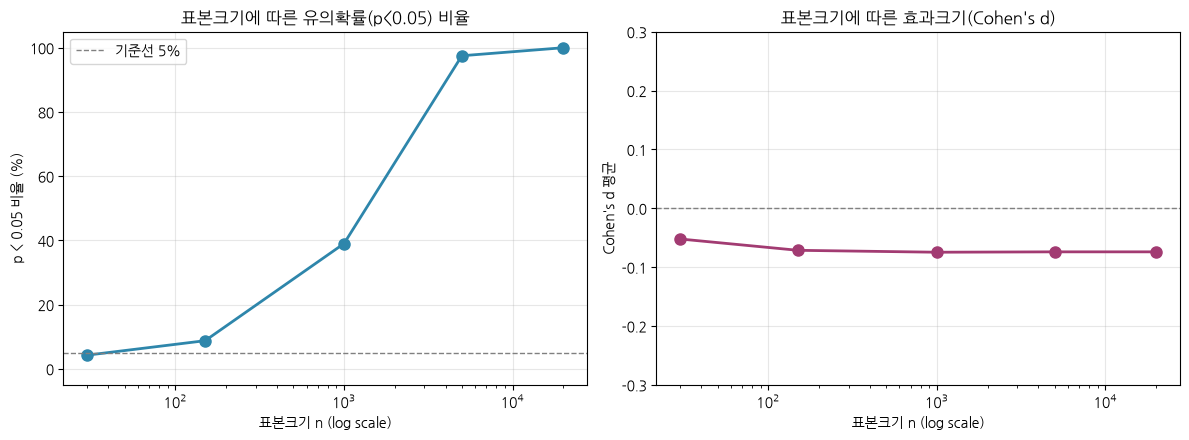

In [38]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats

# 한글 폰트 깨짐 방지 (환경에 맞는 폰트로 바꿔주세요)
plt.rcParams['font.family'] = 'NanumGothic'   # 또는 'Malgun Gothic', 'AppleGothic' 등
plt.rcParams['axes.unicode_minus'] = False

# ── 문제 1: 데이터 준비 ──────────────────────────
penguins = sns.load_dataset('penguins')
mass = penguins.dropna(subset=['body_mass_g', 'species'])
adelie    = mass.loc[mass['species'] == 'Adelie',    'body_mass_g']
chinstrap = mass.loc[mass['species'] == 'Chinstrap', 'body_mass_g']

# ── Q2: Cohen's d 함수 ──────────────────────────
def cohen_d(x, y):
    nx, ny = len(x), len(y)
    sx, sy = np.std(x, ddof=1), np.std(y, ddof=1)
    pooled_s = np.sqrt(((nx - 1) * sx**2 + (ny - 1) * sy**2) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_s

# ── Q3: 모집단 참값 설정 & 시뮬레이션 ──────────────
MU_A, MU_C = adelie.mean(), chinstrap.mean()
SIGMA = np.sqrt(((len(adelie)-1)*adelie.std(ddof=1)**2 + (len(chinstrap)-1)*chinstrap.std(ddof=1)**2)
                / (len(adelie) + len(chinstrap) - 2))

np.random.seed(42)
n_list = [30, 150, 1000, 5000, 20000]
n_reps = 400

n_arr, pct_sig_arr, d_mean_arr = [], [], []
for n in n_list:
    p_values, d_values = [], []
    for _ in range(n_reps):
        sample_a = np.random.normal(MU_A, SIGMA, n)
        sample_c = np.random.normal(MU_C, SIGMA, n)
        _, p = stats.ttest_ind(sample_a, sample_c)
        p_values.append(p)
        d_values.append(cohen_d(sample_a, sample_c))
    p_values = np.array(p_values)
    d_values = np.array(d_values)
    n_arr.append(n)
    pct_sig_arr.append(np.mean(p_values < 0.05) * 100)
    d_mean_arr.append(np.mean(d_values))

print(n_arr, pct_sig_arr, d_mean_arr)   # 값이 잘 채워졌는지 확인용

# ── Q4: 그래프 ──────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(n_arr, pct_sig_arr, marker='o', color='#2E86AB', linewidth=2, markersize=8)
ax[0].set_xscale('log')
ax[0].set_xlabel('표본크기 n (log scale)')
ax[0].set_ylabel('p < 0.05 비율 (%)')
ax[0].set_title('표본크기에 따른 유의확률(p<0.05) 비율')
ax[0].axhline(5, color='gray', linestyle='--', linewidth=1, label='기준선 5%')
ax[0].set_ylim(-5, 105)
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(n_arr, d_mean_arr, marker='o', color='#A23B72', linewidth=2, markersize=8)
ax[1].set_xscale('log')
ax[1].set_xlabel('표본크기 n (log scale)')
ax[1].set_ylabel("Cohen's d 평균")
ax[1].set_title("표본크기에 따른 효과크기(Cohen's d)")
ax[1].axhline(0, color='gray', linestyle='--', linewidth=1)
ax[1].set_ylim(-0.3, 0.3)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1. 같은 32g인데 왜 결론이 갈렸나요?

Q1에서는 실제 표본 그대로(n=151, n=68)를 썼고, Q3의 n=5,000 시뮬레이션은 그보다 훨씬 큰 표본을 인위적으로 만든 것입니다.

차이의 크기(32g, d≈0.074)는 두 경우 모두 동일했습니다. 달라진 것은 표본 크기뿐입니다.

t-검정의 통계량은 대략 t ≈ 효과크기 × √n 형태를 갖기 때문에, 효과크기가 아무리 작아도 n이 커지면 t는 커지고 표준오차는 작아져서 결국 p-값은 0.05 아래로 떨어집니다. 

즉 "32g이라는 차이가 진짜인지 아닌지"는 변한 게 없고, 단지 그 작은 차이를 "통계적으로 확신 있게 검출할 만큼 데이터가 많았는가"만 바뀐 것입니다. 

Q1의 표본은 이 미세한 차이를 검출하기엔 부족했고, n=5,000은 충분했을 뿐입니다.

2. n에 따른 p-값 vs Cohen's d — 한 문장 정리

Q3의 표에서 n이 30→20,000으로 커지는 동안 p-값은 0.48에서 사실상 0으로 급격히 작아졌지만, Cohen's d는 -0.05~-0.07 사이에서 거의 변하지 않았습니다.

한 문장으로: "p-값은 표본크기가 결정하고, 효과크기는 표본크기와 무관하게 모집단이 결정한다."

3. "통계적으로 유의하다" ≠ "실질적으로 의미 있다"

같은 말이 아닙니다. "통계적으로 유의하다"는 **"이 차이가 우연히 생겼을 가능성이 낮다"**는 뜻일 뿐, "이 차이가 실제로 중요하다"는 뜻이 아닙니다.

펭귄 예로 보면: n=20,000에서 얻은 p<0.05는 "Adelie와 Chinstrap의 평균 몸무게가 정확히 같지는 않다"는 것을 매우 확신 있게 말해줄 뿐입니다. 

하지만 그 차이가 실제로는 32g, 즉 Adelie 평균의 0.9%에 불과합니다. 

두 종을 몸무게로 구분하려는 실용적 목적(예: 몸무게만 보고 종을 판별하는 기준을 만드는 것)에는 이 정보가 거의 쓸모가 없습니다. 

"통계적으로 유의함"은 확신의 문제이고, "실질적으로 의미 있음"은 크기·중요성의 문제입니다.

4. A/B 테스트: 클릭률 0.1%p 상승, p=0.001 — 바꿔야 할까요?

이것만으로는 판단할 수 없습니다. p=0.001은 이 차이가 우연이 아닐 가능성이 매우 높다는 뜻이지만, 효과크기(0.1%p)가 실질적으로 의미 있는지는 별개의 질문입니다.

확인해야 할 것들:

표본 크기: A/B 테스트는 보통 수만~수백만 방문자 단위라 검정력이 매우 높습니다. 이런 경우 0.1%p처럼 작은 차이도 쉽게 유의해질 수 있습니다 (Q3에서 확인한 바로 그 현상).

비용 대비 효과: 버튼 색을 바꾸는 데 드는 개발·디자인 비용, 다른 UI 요소와의 충돌 위험 등을 0.1%p 상승이 상쇄할 만큼 가치가 있는지.

비즈니스 임팩트로 환산: 0.1%p가 실제 매출/전환에서 얼마의 금액으로 환산되는지 (트래픽 규모에 따라 크게 달라짐 — 트래픽이 크면 작은 %p도 절대적 금액은 클 수 있음).

즉 p-값은 "우연이 아니다"까지만 말해주고, "바꿀 가치가 있다"는 별도로 효과크기와 비즈니스 맥락을 함께 봐야 판단할 수 있습니다.

5. p-값만 적는 것이 왜 부족한가

p-값 하나만으로는 **"차이가 존재하는가"**만 알 수 있고, **"그 차이가 얼마나 크고 중요한가"**는 전혀 알 수 없습니다. 

특히 표본 크기에 따라 같은 크기의 효과라도 p-값이 크게 달라지므로(Q3에서 확인), p-값만 보고서는 독자가 이 결과의 실질적 무게를 가늠할 방법이 없습니다.

함께 적어야 할 것들:

효과크기(Cohen's d, 상관계수 r 등)와 그 신뢰구간 — 차이의 크기와 추정의 불확실성

원래 척도의 실제 수치 (예: "32g 차이", "0.1%p 상승") — 통계 지표로 변환되기 전 원 단위의 의미

표본 크기(n) — 얼마나 많은 데이터로부터 나온 결론인지

미국통계협회(ASA)가 2016년 성명에서 "p-값 하나로 과학적 결론을 대신하지 말라"고 못박은 것도 바로 이 이유 때문입니다. 

p-값은 결론의 전부가 아니라 여러 증거 중 하나일 뿐입니다.

문제 2 · 그럼 몇 마리를 재야 할까? 난이도 중 · 예상 25분

📖 상황

▸ 문제 1은 "n을 늘리면 유의해진다"를 보여줬습니다. 뒤집어 읽으면 무서운 말입니다 — n이 모자라면 진짜 있는 차이도 놓친다.

▸ 진짜 차이가 있는데 놓치는 잘못을 **제2종 오류(β)**라 하고, 놓치지 않을 확률 1 − β를 **검정력(Power)**이라 부릅니다. 관례적으로 80%를 목표로 삼습니다.

▸ 강의 9장은 이렇게 못박습니다 — "미리 검출하고자 하는 효과크기를 정하고, 설정한 𝛼와 𝛽에 따라 필요한 표본크기 𝓃을 결정해야 합니다."

▸ 이번 문제는 그 계산을 직접 해 봅니다. 실험을 시작하기 전에 하는 계산입니다.

🎯 이 문제로 배우는 것

▸ 제1종·제2종 오류를 구분하고, 효과크기 → 필요 표본수를 산출하는 검정력 분석을 익힙니다. 문제 1의 시뮬레이션 결과가 이론값과 맞는지도 확인합니다.

Q1 · 두 가지 오류를 표로 정리해 봅시다

▸ 강의 9장의 신약 예시를 씁니다. H₀: "신약은 효과가 없다"

▸ 아래 네 칸을 채우세요. 각 칸에 오류의 이름과 무엇을 잃는가를 함께 적으세요.

▸ 코드가 아니라 말로 채우는 문제입니다.

In [39]:
import pandas as pd

table = pd.DataFrame(
    {
        "H0가 참 (실제 효과 없음)": [
            "제1종 오류 (α)\n— 효과 없는 약을 승인 (환자 위험)",
            "올바른 결론 (1-α)\n— 효과 없는 약을 정확히 걸러냄",
        ],
        "H0가 거짓 (실제 효과 있음)": [
            "올바른 결론 (검정력, 1-β)\n— 효과 있는 약을 정확히 찾아냄",
            "제2종 오류 (β)\n— 효과 있는 약을 놓침 (기회 손실)",
        ],
    },
    index=["검정 결과: H0 기각 (효과 있다고 결론)", "검정 결과: H0 기각 못함 (효과 없다고 결론)"],
)

pd.set_option("display.max_colwidth", None)
print(table.to_string())

                                              H0가 참 (실제 효과 없음)                      H0가 거짓 (실제 효과 있음)
검정 결과: H0 기각 (효과 있다고 결론)     제1종 오류 (α)\n— 효과 없는 약을 승인 (환자 위험)  올바른 결론 (검정력, 1-β)\n— 효과 있는 약을 정확히 찾아냄
검정 결과: H0 기각 못함 (효과 없다고 결론)   올바른 결론 (1-α)\n— 효과 없는 약을 정확히 걸러냄      제2종 오류 (β)\n— 효과 있는 약을 놓침 (기회 손실)


제1종 오류(α): "효과 없는 걸 있다고 우김" — 거짓 양성(false positive). 잘못된 약이 세상에 나오는 위험.

제2종 오류(β): "효과 있는 걸 없다고 놓침" — 거짓 음성(false negative). 좋은 약이 세상에 못 나오는 손실.

Q2 · 문제 1의 시뮬레이션이 이론과 맞는지 확인해 봅시다

▸ 문제 1에서 구한 펭귄의 효과크기(d ≈ 0.074)에 대해, n = 30, 150, 1000, 5000, 20000 각각의 이론적 검정력을 계산하세요.

▸ 이 값을 문제 1 Q3의 'p < 0.05 비율'과 나란히 출력해 두 값이 일치하는지 눈으로 확인하세요.

In [40]:
from statsmodels.stats.power import TTestIndPower

analysis = TTestIndPower()

d = 0.074
ns = [30, 150, 1000, 5000, 20000]

print(f'{"n":>8} | {"이론적 검정력":>12}')
print('-' * 25)
for n in ns:
    power = analysis.power(effect_size=abs(d), nobs1=n, alpha=0.05, ratio=1)
    print(f'{n:>8} | {power:>12.4f}')

       n |      이론적 검정력
-------------------------
      30 |       0.0592
     150 |       0.0979
    1000 |       0.3799
    5000 |       0.9590
   20000 |       1.0000


Q3 · 80% 검정력에 필요한 표본수를 구해 봅시다

▸ 유의수준 0.05, 검정력 0.80을 목표로 할 때 집단당 필요한 표본수를 구하세요.

▸ 효과크기 네 가지에 대해 각각 계산해 표로 출력하세요. ① 펭귄의 d ≈ 0.074 ② 0.2(작음) ③ 0.5(중간) ④ 0.8(큼)

In [41]:
import numpy as np
from statsmodels.stats.power import TTestIndPower

analysis = TTestIndPower()

effect_sizes = {
    '펭귄 d≈0.074': 0.074,
    '작음 (0.2)': 0.2,
    '중간 (0.5)': 0.5,
    '큼 (0.8)': 0.8,
}

print(f'{"효과크기":>14} | {"d 값":>8} | {"필요 표본수(집단당)":>18}')
print('-' * 50)
for label, d in effect_sizes.items():
    n = analysis.solve_power(effect_size=d, alpha=0.05, power=0.8)
    n_ceil = int(np.ceil(n))
    print(f'{label:>14} | {d:>8.3f} | {n_ceil:>18}')

          효과크기 |      d 값 |        필요 표본수(집단당)
--------------------------------------------------
    펭귄 d≈0.074 |    0.074 |               2868
      작음 (0.2) |    0.200 |                394
      중간 (0.5) |    0.500 |                 64
       큼 (0.8) |    0.800 |                 26


Q4 · 검정력 곡선을 그려 봅시다

▸ 효과크기를 d = 0.5로 고정하고, 집단당 표본수 n을 5부터 200까지 바꿔가며 검정력 곡선을 그리세요.

▸ 80% 기준선을 수평선으로 함께 그려, 곡선이 이 선을 넘는 지점이 Q3에서 구한 값과 맞는지 확인하세요.

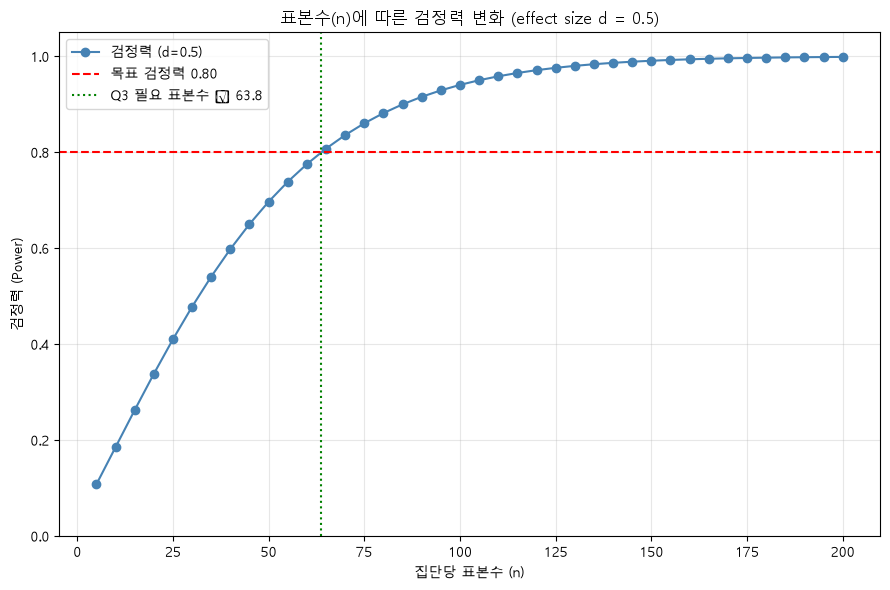

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.power import TTestIndPower

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

analysis = TTestIndPower()

d = 0.5
n_list = np.arange(5, 201, 5)
powers = [analysis.power(effect_size=d, nobs1=n, alpha=0.05, ratio=1) for n in n_list]

n_required = analysis.solve_power(effect_size=d, alpha=0.05, power=0.8)

plt.figure(figsize=(9, 6))
plt.plot(n_list, powers, marker='o', color='steelblue', label='검정력 (d=0.5)')
plt.axhline(0.8, color='red', linestyle='--', label='목표 검정력 0.80')
plt.axvline(n_required, color='green', linestyle=':', label=f'Q3 필요 표본수 ≈ {n_required:.1f}')

plt.title('표본수(n)에 따른 검정력 변화 (effect size d = 0.5)')
plt.xlabel('집단당 표본수 (n)')
plt.ylabel('검정력 (Power)')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

1. 필요 표본수 vs 실제 규모

앞서 계산한 대로 d ≈ 0.074에서 80% 검정력을 확보하려면 집단당 약 2,868마리가 필요합니다. 

그런데 팔머 펭귄 데이터는 전체 3종을 합쳐도 344마리, 종 하나만 놓고 보면 그보다 훨씬 적습니다. 

즉 이 연구는 애초에 32g 차이를 통계적으로 검출할 만큼의 데이터를 가질 수 없었던 연구입니다. 

이건 연구 설계 실수라기보다, "그 정도로 작은 차이를 검출하려던 게 아니라 우연히 관찰된 차이"라고 보는 게 맞습니다. 

검정력 계산은 실험 전에 "이 질문에 답할 수 있는 규모인가"를 미리 걸러주는 역할을 합니다.

2. 검정력 낮은 연구의 "유의하지 않음"이 말해주는 것

검정력이 낮은 상태에서 "유의하지 않다"는 결과는 "차이가 없다"는 증거가 아니라 "차이를 볼 수 있을 만큼 보지 못했다"는 뜻입니다. 

7장 Q5의 Adelie 수컷 회귀에서도 표본이 작아 신뢰구간이 넓었고, 그 결과 "유의하지 않음"이 나왔다고 해서 실제 관계가 없다고 결론 내릴 수 없었던 것과 같은 논리입니다. 

우리가 알 수 있는 것은 "이 표본 크기로는 결론을 내릴 수 없다"는 것뿐이고, 알 수 없는 것은 "진짜 효과가 있는지 없는지" 그 자체입니다. 

이 둘을 혼동하는 게 바로 흔한 통계 오류(부재의 증거 vs 증거의 부재)입니다.

3. 표본수를 실험 전에 정해야 하는 이유

표본수를 미리 정하는 것은 alpha(제1종 오류율)가 약속한 대로 작동하기 위한 전제 조건입니다. 

데이터를 본 뒤 "조금만 더 모아보자"거나 "이쯤에서 멈추자"를 결과에 따라 결정하면, 우연히 유의한 순간에 멈추게 될 확률이 올라가서 실제 제1종 오류율이 5%보다 훨씬 커집니다. 

이게 바로 다음 문제(p-해킹)에서 직접 시뮬레이션으로 확인하게 될 내용입니다 — 사전 설계 없이 표본을 늘리는 것 자체가 규칙을 어기는 행위입니다.

4. alpha를 0.05 → 0.01로 낮추면 n은?


Alpha 0.05 vs 0.01 비교
Alpha 0.05 vs 0.01 비교
          효과크기 |   alpha=0.05 |   alpha=0.01
----------------------------------------------
    펭귄 d≈0.074 |         2868 |         4268
      작음 (0.2) |          394 |          586
      중간 (0.5) |           64 |           96
       큼 (0.8) |           26 |           39

필요한 n은 늘어납니다. alpha를 낮춘다는 건 제1종 오류를 더 엄격하게 통제한다는 뜻이고, 

그러려면 "진짜 신호"라고 더 확신할 수 있을 만큼 증거가 쌓여야 하므로 더 많은 표본이 필요합니다. 

alpha·power·d·n 네 값이 얽혀 있어서, 한쪽 기준(오류 허용치)을 조이면 다른 쪽(표본수)이 그 부담을 떠안게 되는 구조입니다.

5. 효과크기를 정하는 것은 통계 문제인가, 도메인 문제인가

도메인 문제입니다. 통계는 "d = 0.5를 검출하려면 n이 얼마 필요한가"라는 방정식은 풀어주지만, "d가 0.5여야 의미 있는 차이인가"는 답해주지 않습니다. 

펭귄 예시로 치면 "32g 차이가 생물학적으로/생태학적으로 의미 있는 차이인가"는 조류학자가 판단할 몫이고, 

힌트에 나온 혈압약 예시처럼 "몇 mmHg를 낮춰야 임상적으로 의미 있는가"는 의사가 정할 몫입니다. 

통계학자는 그 숫자를 받아서 "그렇다면 표본이 이만큼 필요하다"고 계산해주는 역할일 뿐, 그 숫자 자체를 정해주지 않습니다. 

이 구분을 못 하면 "통계적으로 유의함"과 "실질적으로 중요함"을 혼동하는 흔한 함정에 빠지게 됩니다.

문제 3 · 유의한 결과는 '만들어질' 수 있다 난이도 중 · 예상 25분

📖 상황

▸ 심리학 분야의 과거 연구 100건을 재실험한 결과, 원래 유의했던 97건 중 36건만 다시 유의했습니다(강의 9장). 이것이 **재현성 위기(Reproducibility Crisis)**입니다.

▸ 원인 중 하나는 p-해킹 — 의도했든 아니든 p-값을 0.05 아래로 밀어 넣는 행위입니다.

▸ 이번 문제는 아무 차이도 없는 두 집단을 놓고, 분석 방식만 바꿔가며 "유의한 결과"를 얼마나 만들어낼 수 있는지 직접 세어 봅니다.

▸ 진짜 차이가 없으므로 유의하다는 결론은 전부 제1종 오류입니다. 절차를 지켰다면 5%여야 합니다.

🎯 이 문제로 배우는 것

▸ 정직한 분석 / 표본 추가형 / 다중비교형 세 가지의 제1종 오류율을 직접 세어 비교하고, 다중비교 보정이 왜 필요한지 확인합니다.

Q1 · 정직한 분석의 제1종 오류율을 확인해 봅시다

▸ 기준선을 먼저 만듭니다. 각 집단에서 20명씩 뽑아 딱 한 번만 t-검정하세요.

▸ 이것을 N_SIM번 반복해 p < 0.05가 나온 비율을 출력하세요.

▸ 이 값이 유의수준 0.05와 가까운지 확인하세요.

In [43]:
import numpy as np
from scipy import stats

SEED = 42
N_SIM = 10000

rng = np.random.default_rng(SEED)

count_significant = 0

for _ in range(N_SIM):
    group_a = rng.normal(0, 1, 20)
    group_b = rng.normal(0, 1, 20)
    t_stat, p_value = stats.ttest_ind(group_a, group_b)
    if p_value < 0.05:
        count_significant += 1

false_positive_rate = count_significant / N_SIM

print(f'반복 횟수(N_SIM): {N_SIM}')
print(f'p < 0.05가 나온 횟수: {count_significant}')
print(f'제1종 오류율(정직한 분석): {false_positive_rate:.4f} ({false_positive_rate*100:.2f}%)')
print(f'유의수준 alpha = 0.05 와의 차이: {abs(false_positive_rate - 0.05):.4f}')

반복 횟수(N_SIM): 10000
p < 0.05가 나온 횟수: 486
제1종 오류율(정직한 분석): 0.0486 (4.86%)
유의수준 alpha = 0.05 와의 차이: 0.0014


Q2 · 해킹 ① — 결과를 보고 표본을 더 모으면

▸ 강의 9장이 첫 번째로 꼽은 p-해킹입니다 — "결과를 보며 표본크기를 늘려서는 안 됨"

▸ 다음 규칙을 따르는 'p-해커'를 만드세요.

▸ 각 집단 20명으로 시작해 t-검정

▸ p < 0.05면 "찾았다!" 하고 즉시 멈춤

▸ p ≥ 0.05면 각 집단에 10명씩 추가해 다시 검정

▸ 이 과정을 최대 5번까지 반복

▸ N_SIM번 반복해 한 번이라도 p < 0.05를 얻은 비율을 출력하고, Q1의 값과 비교하세요.

In [44]:
import numpy as np
from scipy import stats

SEED = 42
N_SIM = 10000

rng = np.random.default_rng(SEED)

def p_hacker_peek(rng, max_looks=5, start_n=20, add_n=10):
    """
    각 집단 20명으로 시작해 t-검정을 반복.
    p < 0.05가 나오면 즉시 멈추고, 아니면 각 집단에 10명씩 추가해 최대 5번까지 반복.
    """
    group_a = list(rng.normal(0, 1, start_n))
    group_b = list(rng.normal(0, 1, start_n))

    for _ in range(max_looks):
        t_stat, p_value = stats.ttest_ind(group_a, group_b)
        if p_value < 0.05:
            return True  # "찾았다!"
        group_a.extend(rng.normal(0, 1, add_n))
        group_b.extend(rng.normal(0, 1, add_n))

    return False  # 5번 다 봤는데도 못 찾음

count_found = 0
for _ in range(N_SIM):
    if p_hacker_peek(rng):
        count_found += 1

hacked_rate = count_found / N_SIM

print(f'반복 횟수(N_SIM): {N_SIM}')
print(f'한 번이라도 p < 0.05를 찾은 횟수: {count_found}')
print(f'제1종 오류율(표본 추가형 해킹): {hacked_rate:.4f} ({hacked_rate*100:.2f}%)')
print(f'Q1(정직한 분석) 대비 배율: {hacked_rate/0.05:.2f}배')

KeyboardInterrupt: 

Q3 · 해킹 ② — 지표를 20개 재서 하나만 보고하면

▸ 강의 9장의 두 번째 p-해킹입니다 — "마음에 드는 해석만 보고해서는 안 됨"

▸ 이번엔 표본을 추가하지 않습니다. 대신 아무 차이 없는 지표 20개를 각각 20명씩 검정하고, 하나라도 유의하면 그것만 보고합니다.

▸ N_SIM번 반복해 성공률을 출력하세요.

▸ 이론값 1 − 0.95²⁰과 나란히 출력해 비교하세요.

In [ ]:
import numpy as np
from scipy import stats

SEED = 42
N_SIM = 10000
N_METRICS = 20

rng = np.random.default_rng(SEED)

count_found = 0
for _ in range(N_SIM):
    p_values = []
    for _ in range(N_METRICS):
        group_a = rng.normal(0, 1, 20)
        group_b = rng.normal(0, 1, 20)
        _, p_value = stats.ttest_ind(group_a, group_b)
        p_values.append(p_value)

    if any(p < 0.05 for p in p_values):
        count_found += 1

hacked_rate = count_found / N_SIM
theoretical_rate = 1 - 0.95 ** N_METRICS

print(f'반복 횟수(N_SIM): {N_SIM}, 지표 개수: {N_METRICS}')
print(f'시뮬레이션 성공률(다중비교형 해킹): {hacked_rate:.4f} ({hacked_rate*100:.2f}%)')
print(f'이론값 1 - 0.95^20:              {theoretical_rate:.4f} ({theoretical_rate*100:.2f}%)')
print(f'차이: {abs(hacked_rate - theoretical_rate):.4f}')

반복 횟수(N_SIM): 10000, 지표 개수: 20
시뮬레이션 성공률(다중비교형 해킹): 0.6398 (63.98%)
이론값 1 - 0.95^20:              0.6415 (64.15%)
차이: 0.0017


Q4 · 세 결과를 나란히 놓고, 보정 효과까지 확인해 봅시다

▸ Q3의 방식에 본페로니 보정을 적용하면 오류율이 어떻게 되는지 계산하세요. (지표가 20개이므로 각 검정의 기준을 0.05 / 20으로 낮춥니다)

▸ Q1 ~ Q3 결과와 보정 후 결과, 총 네 개를 막대그래프로 그리세요.

▸ α = 5% 기준선을 수평선으로 함께 표시해 어느 것이 선을 넘는지 한눈에 보이게 하세요.

방식                             | 제1종 오류율
---------------------------------------------
Q1 정직한 분석                      | 4.81%
Q2 표본 추가형                      | 12.12%
Q3 다중비교형(보정 전)                 | 63.42%
Q4 다중비교형(보정 후)                 | 5.18%


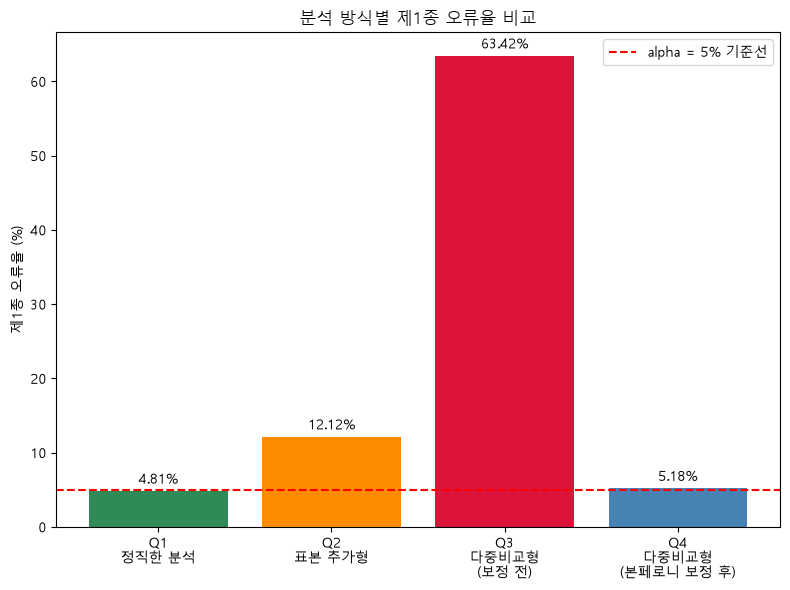

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

SEED = 42
N_SIM = 10000
N_METRICS = 20

# ---- Q1: 정직한 분석 (벡터화) ----
rng = np.random.default_rng(SEED)
a = rng.normal(0, 1, (N_SIM, 20))
b = rng.normal(0, 1, (N_SIM, 20))
_, p = stats.ttest_ind(a, b, axis=1)
rate_q1 = np.mean(p < 0.05)

# ---- Q2: 표본 추가형 해킹 (라운드별 벡터화) ----
rng = np.random.default_rng(SEED)
group_a = rng.normal(0, 1, (N_SIM, 20))
group_b = rng.normal(0, 1, (N_SIM, 20))
found = np.zeros(N_SIM, dtype=bool)

for look in range(5):
    _, p = stats.ttest_ind(group_a, group_b, axis=1)
    found |= (p < 0.05)
    if look < 4:
        add_a = rng.normal(0, 1, (N_SIM, 10))
        add_b = rng.normal(0, 1, (N_SIM, 10))
        group_a = np.concatenate([group_a, add_a], axis=1)
        group_b = np.concatenate([group_b, add_b], axis=1)

rate_q2 = np.mean(found)

# ---- Q3 & Q4: 다중비교형 해킹 (벡터화, 한 번에 둘 다 계산) ----
rng = np.random.default_rng(SEED)
a3 = rng.normal(0, 1, (N_SIM, N_METRICS, 20))
b3 = rng.normal(0, 1, (N_SIM, N_METRICS, 20))
_, p3 = stats.ttest_ind(a3, b3, axis=2)  # shape (N_SIM, N_METRICS)

rate_q3 = np.mean(np.any(p3 < 0.05, axis=1))

alpha_corrected = 0.05 / N_METRICS
rate_q4 = np.mean(np.any(p3 < alpha_corrected, axis=1))

# ---- 결과 요약 ----
labels = ['Q1\n정직한 분석', 'Q2\n표본 추가형', 'Q3\n다중비교형\n(보정 전)', 'Q4\n다중비교형\n(본페로니 보정 후)']
rates_pct = [rate_q1*100, rate_q2*100, rate_q3*100, rate_q4*100]

print(f'{"방식":<30} | {"제1종 오류율"}')
print('-'*45)
for label, rate in zip(['Q1 정직한 분석', 'Q2 표본 추가형', 'Q3 다중비교형(보정 전)', 'Q4 다중비교형(보정 후)'], rates_pct):
    print(f'{label:<30} | {rate:.2f}%')

# ---- 그래프 ----
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 6))
colors = ['seagreen', 'darkorange', 'crimson', 'steelblue']
bars = plt.bar(labels, rates_pct, color=colors)
plt.axhline(5, color='red', linestyle='--', label='alpha = 5% 기준선')

for bar, rate in zip(bars, rates_pct):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f'{rate:.2f}%', ha='center', fontsize=10)

plt.title('분석 방식별 제1종 오류율 비교')
plt.ylabel('제1종 오류율 (%)')
plt.legend()
plt.tight_layout()
plt.show()

1. Q1이 5%에 가까웠던 것이 뜻하는 바

가설검정이 보장하는 것은 "진짜로 아무 차이가 없을 때, 절차를 정직하게 지켰다면 우연히 유의하다고 잘못 판단할 확률이 정확히 alpha(5%) 이하"라는 점입니다. 

Q1의 4.86%는 바로 이 약속이 실제로 지켜지는 모습을 확인한 것입니다. 

즉 가설검정은 "차이가 없다는 것을 증명해주는 도구"가 아니라, **"틀릴 확률을 미리 정한 수준으로 관리해주는 도구"**입니다.

2. Q2와 Q3에서 오류율이 뛴 이유 — 같은 메커니즘인가, 다른가

두 해킹은 겉모습은 다르지만 뿌리는 같습니다.

Q2는 같은 가설을 여러 번 다시 물어본 것입니다. 

20명 → 30명 → 40명... 매번 검정할 때마다 "이번엔 우연히 유의하게 나올까"를 다시 뽑는 셈이라, 다섯 번의 기회가 쌓이면서 최소 한 번은 걸릴 확률이 올라갑니다.

Q3는 서로 다른 가설(지표) 20개를 물어보고 그중 하나만 골라 보고한 것입니다. 20번 중 어느 하나라도 우연히 유의하면 되니 역시 기회가 20번 쌓입니다.

표현은 "표본을 늘렸다"와 "지표를 늘렸다"로 다르지만, 본질은 둘 다 **"검정할 기회를 여러 번 만들고, 그중 하나가 걸리기를 기다린 것"**입니다. 

이걸 다중검정 문제(multiple testing problem)라고 부르며, 어느 쪽이든 유의수준 alpha가 원래 뜻했던 "5%짜리 위험"을 훨씬 웃도는 실제 위험으로 부풀립니다.

3. Q3의 결과가 뜻하는 것 — 신뢰할 수 있는가

Q3의 63.98%는 "아무 차이도 없는데, 지표를 20개 재면 10번 중 6번 이상은 뭔가 하나는 유의하게 보인다"는 뜻입니다. 

동전을 20번 던져 최소 한 번은 앞면이 나올 확률이 거의 1인 것과 같은 원리입니다. 

그러므로 "지표 20개를 재고 유의한 하나만 보고한다"는 연구는 그 결과 하나만 놓고는 신뢰할 수 없습니다. 

그 유의함이 진짜 신호인지 아니면 20번 중 우연히 걸린 것인지 그 결과만으로는 구별할 방법이 없기 때문입니다.

4. HARKing은 Q2·Q3 중 어느 쪽과 닮았나

Q3와 닮았습니다. HARKing(Hypothesizing After Results are Known)은 결과를 먼저 보고 나서 "원래 이 가설을 검증하려 했다"고 이야기를 짜맞추는 행위입니다. 

Q3에서 20개 지표 중 우연히 유의했던 하나를 "이게 바로 우리가 찾던 효과다"라고 사후에 골라 보고하는 구조와 정확히 같습니다. 

Q2는 하나의 가설을 계속 다시 검정한 것이라 성격이 조금 다르지만, Q3는 애초에 여러 후보 중 사후에 하나를 골라낸다는 점에서 HARKing의 전형입니다.

5. 사전 등록이 Q2와 Q3를 각각 어떻게 막아주는가

Q2 방지: 사전 등록에 "표본수는 N명으로 고정하고, 데이터를 다 모은 뒤 딱 한 번만 검정한다"를 명시하면, 결과를 보며 표본을 늘리는 것 자체가 절차 위반이 되어 원천 차단됩니다.

Q3 방지: 사전 등록에 "검증할 가설(지표)은 이것 하나다"라고 미리 못 박아두면, 나중에 20개 중 하나를 골라 보고하는 게 불가능해집니다. 

        혹은 20개를 다 보겠다고 미리 밝혔다면, 다중비교 보정을 적용하겠다는 계획까지 함께 등록해야 합니다.

두 경우 모두 핵심은 같습니다 — "결과를 보기 전에 규칙을 정하고, 그 규칙을 결과가 나온 뒤에 바꾸지 않는다."

6. 문제 2의 '표본수 사전 설계'가 Q2를 막는 역할

문제 2에서 배운 검정력 분석(solve_power)은 "이 정도 효과를 이 정도 확률로 잡으려면 n이 얼마 필요한가"를 실험 시작 전에 계산해줍니다. 

이걸 미리 해두면 "일단 20명으로 시작해서 안 되면 더 모으자"는 식의 접근 자체가 필요 없어집니다. 

즉 표본수 사전 설계는 Q2형 해킹이 벌어질 수 있는 여지를 애초에 없애는 예방책입니다 — 필요한 n을 계산으로 미리 정해두면, "결과를 보며 표본을 늘리는" 유혹이 파고들 틈이 사라지는 것입니다.

문제 4 · 교란요인을 지우는 두 가지 방법 — 통제와 무작위화
난이도 중 · 예상 30분

📖 상황

▸ 7장 문제 1에서 이상한 것을 봤습니다. 
  
  펭귄 부리는 전체로 보면 길수록 얇은데, 종별로 나눠 보면 길수록 두꺼웠습니다. 그때 "이 현상에는 이름이 붙어 있고, 다음 시간 인과추론에서 다시 만난다"고 적어 두었습니다. 이제 그 이름을 붙입니다.

▸ 원인은 중첩요인(교란변수, Confounder) — '종'이 부리 길이와 두께 양쪽에 영향을 주고 있었습니다. 여기서 생겨난 가짜 음의 관계를 **허위상관(Spurious Correlation)**이라 부릅니다.

▸ 교란요인을 지우는 길은 두 갈래입니다.

▸ ① 통제 — 층별로 나눠 보거나, 회귀식에 함께 넣기 (강의 10.3)

▸ ② 무작위화 — 애초에 동전을 던져 배정하기, 즉 무작위 통제 실험(RCT) (강의 10.2)

▸ 이번 문제는 두 방법을 나란히 써 보고, 왜 무작위화가 더 강력한지 확인합니다.

🎯 이 문제로 배우는 것

▸ 실제 데이터로 허위상관을 진단하고 통제로 걷어낸 뒤, 시뮬레이션으로 무작위 배정의 힘을 확인합니다. 그리고 두 방법의 결정적 차이를 이해합니다.

In [ ]:
# 문제 4 · 데이터 준비 (1/2) — 실행만 하세요
# 펭귄 부리 데이터: 7장 문제 1에서 봤던 그 데이터입니다.
bills = penguins.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'species'])

print("분석에 사용할 데이터: %d 행\n" % len(bills))
print("종별 부리 평균 —— '종'이 두 변수 모두에 영향을 주고 있다는 단서")
print(bills.groupby('species')[['bill_length_mm', 'bill_depth_mm']].mean().round(2))

분석에 사용할 데이터: 342 행

종별 부리 평균 —— '종'이 두 변수 모두에 영향을 주고 있다는 단서
           bill_length_mm  bill_depth_mm
species                                 
Adelie              38.79          18.35
Chinstrap           48.83          18.42
Gentoo              47.50          14.98


Q1 · 전체 데이터로 부리 길이와 두께의 관계를 회귀로 확인해 봅시다

▸ bill_depth_mm(반응변수)을 bill_length_mm(설명변수)으로 설명하는 단순회귀를 적합하세요.

▸ 기울기 계수와 p-값을 출력하세요.

▸ 이 결과만 보고했다면 어떤 결론이 되는지 한 줄로 적으세요.

In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(formula='bill_depth_mm ~ bill_length_mm', data=bills).fit()

slope = model.params['bill_length_mm']
p_value = model.pvalues['bill_length_mm']

print(f'기울기 계수: {slope:.4f}')
print(f'p-값: {p_value:.4e}')

기울기 계수: -0.0850
p-값: 1.1197e-05


Q2 · 종별로 층을 나눠 같은 회귀를 다시 해 봅시다

▸ 세 종(Adelie · Chinstrap · Gentoo) 각각에 대해 Q1과 똑같은 회귀를 적합하세요.

▸ 종별로 n, 기울기 계수, p-값을 표로 정리해 출력하세요.

▸ 이것은 강의 10장의 "중학교 1·2·3학년으로 층을 나눈 후, 각 학년을 따로 해석" 과 똑같은 작업입니다.

In [ ]:
import statsmodels.formula.api as smf
import pandas as pd

results = []
for species, group in bills.groupby('species'):
    model = smf.ols(formula='bill_depth_mm ~ bill_length_mm', data=group).fit()
    results.append({
        '종': species,
        'n': len(group),
        '기울기': model.params['bill_length_mm'],
        'p-값': model.pvalues['bill_length_mm']
    })

result_df = pd.DataFrame(results)
print(result_df.to_string(index=False))

        종   n      기울기          p-값
   Adelie 151 0.178834 6.674141e-07
Chinstrap  68 0.222212 1.525539e-09
   Gentoo 123 0.204844 1.015502e-15


Q3 · 종을 회귀식에 함께 넣어 통제해 봅시다

▸ 이번엔 층을 나누지 않고, 회귀식에 '종'을 함께 넣어 한 번에 적합하세요.

▸ Q1의 결과와 기울기·p-값·R²를 나란히 출력해 비교하세요.

In [ ]:
import statsmodels.formula.api as smf
import pandas as pd

model_q1 = smf.ols(formula='bill_depth_mm ~ bill_length_mm', data=bills).fit()
model_q3 = smf.ols(formula='bill_depth_mm ~ bill_length_mm + C(species)', data=bills).fit()

comparison = pd.DataFrame({
    'Q1 (종 미고려)': [model_q1.params['bill_length_mm'], model_q1.pvalues['bill_length_mm'], model_q1.rsquared],
    'Q3 (종 통제)':   [model_q3.params['bill_length_mm'], model_q3.pvalues['bill_length_mm'], model_q3.rsquared],
}, index=['기울기', 'p-값', 'R²'])

print(comparison.round(6))

     Q1 (종 미고려)  Q3 (종 통제)
기울기   -0.085021   0.199894
p-값    0.000011   0.000000
R²     0.055250   0.768996


In [ ]:
# 문제 4 · 데이터 준비 (2/2) — 실행만 하세요
# 같은 학생 2,000명에게 '새 온라인 강의'를 배정하는 두 가지 방식
TRUE_EFFECT = 5.0                      # 강의의 진짜 효과: 기말고사 +5점
rng = np.random.default_rng(279)
n = 2000

pre_score   = rng.normal(60, 10, n)    # 교란요인 ① 사전 성적
study_hours = rng.normal(10,  3, n)    # 교란요인 ② 주당 학습시간

# 잠재결과 — 두 교란요인은 결과(기말고사 성적)에도 직접 영향을 줍니다
Y0 = 20 + 0.7 * pre_score + 0.8 * study_hours + rng.normal(0, 5, n)  # 강의를 안 들었을 때
Y1 = Y0 + TRUE_EFFECT                                                 # 강의를 들었을 때

# (A) 관찰연구 — 성적 좋고 열심인 학생이 스스로 신청 (선택 편향)
signup_logit = -0.6 + 0.10 * (pre_score - 60) + 0.20 * (study_hours - 10)
course_obs = rng.binomial(1, 1 / (1 + np.exp(-signup_logit)))

# (B) 무작위 통제 실험 — 동전을 던져 배정
course_rct = rng.binomial(1, 0.5, n)

df_obs = pd.DataFrame({'pre_score': pre_score, 'study_hours': study_hours,
                       'course': course_obs, 'final_score': np.where(course_obs == 1, Y1, Y0)})
df_rct = pd.DataFrame({'pre_score': pre_score, 'study_hours': study_hours,
                       'course': course_rct, 'final_score': np.where(course_rct == 1, Y1, Y0)})

print("참 효과(우리가 추정해야 하는 값): %.1f점\n" % TRUE_EFFECT)
print("관찰연구 df_obs — 수강생 %d명 (%.1f%%)" % (df_obs['course'].sum(), df_obs['course'].mean()*100))
print("RCT      df_rct — 수강생 %d명 (%.1f%%)" % (df_rct['course'].sum(), df_rct['course'].mean()*100))

참 효과(우리가 추정해야 하는 값): 5.0점

관찰연구 df_obs — 수강생 751명 (37.5%)
RCT      df_rct — 수강생 1012명 (50.6%)


Q4 · 관찰연구에서 처치군과 대조군은 애초에 다릅니다

▸ 아래 데이터 준비 셀을 실행하면 학생 2,000명의 데이터 두 벌이 만들어집니다. 같은 학생들인데 강의 배정 방식만 다릅니다.

▸ 먼저 **관찰연구(df_obs)**를 보세요. 성적이 좋고 열심인 학생이 스스로 신청한 상황입니다.

▸ ① 수강생과 비수강생의 final_score 단순 평균 차이를 계산하세요.

▸ ② 두 집단의 교란요인 평균(pre_score, study_hours)도 함께 비교하세요.

▸ 참 효과는 5.0점입니다. 단순 평균 차이가 이 값과 얼마나 다른지 확인하세요.

In [ ]:
group_means = df_obs.groupby('course')[['pre_score', 'study_hours', 'final_score']].mean()
print('집단별 평균 (course=0: 비수강생, course=1: 수강생)')
print(group_means.round(3))

naive_diff = group_means.loc[1, 'final_score'] - group_means.loc[0, 'final_score']
print(f'단순 평균 차이(final_score): {naive_diff:.3f}점')
print(f'참 효과: {TRUE_EFFECT:.1f}점')
print(f'편향(단순 차이 - 참 효과): {naive_diff - TRUE_EFFECT:.3f}점')

for col in ['pre_score', 'study_hours']:
    diff = group_means.loc[1, col] - group_means.loc[0, col]
    print(f'{col} 평균 차이(수강생 - 비수강생): {diff:.3f}')

집단별 평균 (course=0: 비수강생, course=1: 수강생)
        pre_score  study_hours  final_score
course                                     
0          57.052        9.714       67.873
1          64.739       11.096       79.209
단순 평균 차이(final_score): 11.337점
참 효과: 5.0점
편향(단순 차이 - 참 효과): 6.337점
pre_score 평균 차이(수강생 - 비수강생): 7.687
study_hours 평균 차이(수강생 - 비수강생): 1.382


Q5 · 같은 학생들을 동전 던지기로 배정하면 어떻게 될까요

▸ 이제 **RCT(df_rct)**에 대해 Q4와 똑같은 두 가지 계산을 하세요.

▸ 단순 평균 차이를 참 효과 5.0점과 비교하세요.

▸ 두 방식의 교란요인 균형을 하나의 표로 정리하면 대비가 선명해집니다. (행: pre_score, study_hours / 열: 관찰연구 차이, RCT 차이)

In [46]:
means_obs = df_obs.groupby('course')[['pre_score', 'study_hours', 'final_score']].mean()
means_rct = df_rct.groupby('course')[['pre_score', 'study_hours', 'final_score']].mean()

diff_rct_final = means_rct.loc[0, 'final_score']

print('RCT 집단별 평균 (course=0: 비수강생, course=1: 수강생)')
print(means_rct.round(3))
print(f'\nRCT 단순 평균 차이(final_score): {diff_rct_final:.3f}점')
print(f'참 효과: {TRUE_EFFECT:.1f}점')
print(f'편향(단순 차이 - 참 효과): {diff_rct_final - TRUE_EFFECT:.3f}점')

balance = pd.DataFrame({
    '관찰연구': [
        means_obs.loc[0, 'pre_score'],
        means_obs.loc[0, 'study_hours'],
    ],
    'RCT': [
        means_rct.loc[0, 'pre_score'],
        means_rct.loc[0, 'study_hours'],
    ],
}, index=['pre_score', 'study_hours'])

print('\n교란요인 균형 비교 (수강생 - 비수강생 평균 차이)')
print(balance.round(3))

RCT 집단별 평균 (course=0: 비수강생, course=1: 수강생)
        pre_score  study_hours  final_score
course                                     
0          59.903       10.237       70.262
1          59.974       10.229       75.242

RCT 단순 평균 차이(final_score): 70.262점
참 효과: 5.0점
편향(단순 차이 - 참 효과): 65.262점

교란요인 균형 비교 (수강생 - 비수강생 평균 차이)
               관찰연구     RCT
pre_score    57.052  59.903
study_hours   9.714  10.237


문제 4의 여섯 질문에 답해보겠습니다.

1. Q1은 음수, Q2·Q3는 양수 — 부호가 뒤집힌 이유와 이름

Q1은 '종'이라는 변수를 완전히 무시하고 342마리 전체를 하나로 뭉뚱그렸습니다. 

그런데 종마다 부리 길이·두께의 절대적인 수준 자체가 다릅니다(Gentoo는 길고 얇고, Adelie는 짧고 두꺼움). 

이 종 간 차이가 워낙 커서, 종 내부의 진짜 관계(길수록 두껍다)를 뒤덮고 전체적으로는 반대 방향의 관계처럼 보이게 만든 것입니다. 

이 현상의 이름은 **심슨의 역설(Simpson's Paradox)**입니다 — 부분집합(종별)에서는 성립하는 관계가, 집단을 합치면 방향이 뒤집히거나 사라지는 현상입니다. 

여기서 '종'이 바로 그 원인이 되는 교란변수입니다.

2. Q2(층별 분석) vs Q3(다중회귀) — 차이와 층이 많아질 때

두 방법 모두 '종'의 효과를 걷어내 같은 결론(양의 기울기)에 도달했지만 접근 방식이 다릅니다.

**Q2(층별 분석)**는 종마다 완전히 독립된 회귀를 따로 적합합니다. 그래서 종마다 기울기가 달라도 되고(0.18, 0.22, 0.20으로 실제로 조금씩 다름), 유연하지만 각 층의 표본이 그 층 데이터로만 제한됩니다.

**Q3(다중회귀)**는 데이터 전체를 한 번에 쓰면서 절편만 종별로 다르게 허용하고, 기울기는 모든 종에 공통(0.1999)이라고 가정합니다.

층이 아주 많아지면 다중회귀(Q3)가 유리합니다. 층별 분석은 층이 많아질수록 층 하나당 표본 수가 줄어들어 추정이 불안정해지지만, 

다중회귀는 전체 데이터를 계속 함께 써서 추정치가 더 안정적입니다. 대신 "기울기가 모든 층에서 같다"는 가정이 실제로 맞는지는 확인이 필요합니다.

3. Q4 관찰연구의 편향 — 교란요인 균형표 근거

균형표를 보면 수강생은 비수강생보다 pre_score가 평균 7.687점, study_hours가 1.382시간 더 높았습니다. 

즉 수강생 집단은 애초에 "강의를 듣지 않았어도 성적이 더 좋았을" 사람들로 치우쳐 있었습니다. 

이 때문에 단순 평균 차이(11.337점)에는 진짜 강의 효과(5.0점)와, 원래부터 실력이 좋은 학생들이 몰린 데서 오는 선택 편향(약 6.3점)이 섞여 들어가 참값을 크게 웃돌게 된 것입니다.

4. Q5의 RCT는 아무것도 통제 안 했는데 왜 정확했나

강의 10장의 문장 그대로입니다 — "중첩요인을 확인하지 않더라도, 그 효과를 무작위를 이용하여 무효화할 수 있으므로, 알고자 하는 변수의 효과만 추정 가능합니다." 

동전을 던져 배정했기 때문에 수강생과 비수강생의 pre_score, study_hours 평균이 우연 수준(0.071, -0.008)까지 저절로 같아졌습니다. 

두 집단이 관찰한 변수뿐 아니라 관찰하지 못한 변수까지 통계적으로 동등해지므로, 

남는 차이는 강의 효과뿐이게 됩니다. 이건 "통제해서" 얻은 결과가 아니라 "애초에 차이가 생기지 않도록" 만든 결과입니다.

5. 통제(Q3) vs 무작위화(Q5)의 결정적 차이

통제는 이름을 아는 교란요인만 지울 수 있습니다. 

Q3에서 지운 건 '종' 하나뿐이고, 만약 성별·서식지·측정 연도 같은 다른 교란요인이 있었다면 회귀식에 넣지 않는 한 그대로 남습니다. 

반면 무작위화는 이름도 모르는 교란요인까지 통계적으로 두 집단에 고르게 흩뿌립니다. 

그래서 아직 모르는 교란요인이 있을 가능성이 있다면 무작위화(RCT)가 훨씬 안전합니다 

이것이 RCT를 "인과추론의 황금 표준"이라 부르는 이유입니다. 통제는 "내가 생각해낸 목록이 완전하다"는 보장이 없다는 근본적 한계를 안고 있습니다.

6. 현실에서 RCT가 늘 가능한가 — 불가능한 예 두 가지

RCT가 늘 가능한 건 아닙니다. 대표적으로:

- 윤리적으로 불가능한 경우: 담배와 건강의 관계를 보려고 사람들을 무작위로 "흡연 집단"과 "비흡연 집단"에 강제 배정할 수는 없습니다. 해로울 수 있는 처치를 강제하는 건 연구윤리상 허용되지 않습니다.

- 현실적으로 불가능한 경우: 최저임금 인상이 고용에 미치는 영향을 보려고 특정 지역에만 무작위로 최저임금을 인상시킬 수 없습니다. 

정책은 법과 행정 절차를 따라야 하고, 비용·시간·정치적 제약 때문에 특정 집단에만 무작위로 적용하기 어렵습니다.

이런 상황에서 관찰 데이터만으로 인과효과에 다가가려는 시도가 다음 문제(PSM, DiD)의 출발점이 됩니다.